<a href="https://colab.research.google.com/github/harabou/Biostat_Kyoto_pref/blob/main/fashion_kadai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ファッションアイテム画像の分類  Classification of Fashion Item Images
10種類のファッションアイテム画像(シャツ、ドレス、かばん、靴等)をニューラルネットワークで分類する Classifying images of 10 types of fashion items (shirts, dresses, bags, shoes, etc.) using a neural network

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 画像データの読み込み Loading Image Data


In [ ]:
%matplotlib inline
!pip install japanize-matplotlib

import numpy as np
import tensorflow as tf
from tensorflow.keras import datasets
import matplotlib.pyplot as plt
import japanize_matplotlib


(x_train, y_train), (x_test, y_test) = datasets.fashion_mnist.load_data()


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.1/4.1 MB 61.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for japanize-matplotlib: filename=japanize_matplotlib-1.1.3-py3-none-any.whl size=4120257 sha256=159a3082dd96d1eedaee9c57dffb5aff6b835a8f0030cc99e6a26172a3111e51
  Stored in directory: /root/.cache/pip/wheels/c1/f7/9b/418f19a7b9340fc16e071e89efc379aca68d40238b258df53d
Successfully built japanize-matplotlib
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


画像の枚数と画素数を確認する Check the number of images and the number of pixels

In [ ]:
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
print("訓練用画像の枚数と画素数")
print(         )

print()

# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
print("テスト用画像の枚数と画素数")
print(         )


訓練用画像の枚数と画素数


テスト用画像の枚数と画素数



テスト用画像の1枚目の多次元配列を表示してみる

In [ ]:
# 途中で改行されないように、一行に表示できる文字数を200文字に変更
np.set_printoptions(linewidth=200)


print(x_train[0])

[[  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   1   0   0  13  73   0   0   1   4   0   0   0   0   1   1   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   3   0  36 136 127  62  54   0   0   0   1   3   4   0   0   3]
 [  0   0   0   0   0   0   0   0   0   0   0   0   6   0 102 204 176 134 144 123  23   0   0   0   0  12  10   0]
 [  0   0   0   0   0   0   0   0   0   0   0   0   0   0 155 236 207 178 107 156 161 109  64  23  77 130  72  15]
 [  0   0   0   0   0   0   0   0   0   0   0   1   0  69 207 223 218 216 216 163 127 121 122 146 141  88 172  66]
 [  0   0   0   0   0   0   0   0   0   1   1   1   0 200 232 232 233 229 223 22

## 訓練用画像の表示 Displaying Training Images

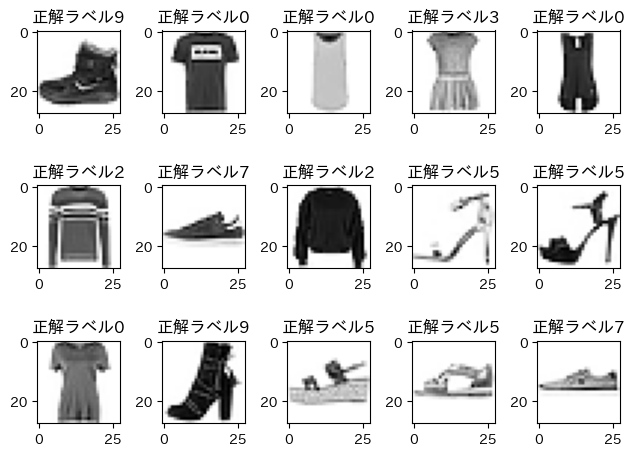

In [ ]:
fig = plt.figure()


for i in range(0,15):

  ax = fig.add_subplot(3, 5, i+1)

  ax.set_title("正解ラベル" + str(y_train[i]))

  ax.imshow(x_train[i], cmap='Greys')

fig.tight_layout()

plt.show()

## 画像の正規化 Image Normalization
画素値が0から1の範囲に収まるように前処理を行う Perform preprocessing so that the pixel values fall within the range of 0 to 1.

In [ ]:
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
x_train = x_train / 255.0
x_test = x_test / 255.0

カテゴリ変数をone-hotエンコーディングする One-hot encoding of categorical variables

In [ ]:
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import datasets

# 誤って複数回ワンホットエンコーディングされるのを防ぐため、元のラベルデータを再ロードします。
(_, y_train_original), (_, y_test_original) = datasets.fashion_mnist.load_data()

print("エンコーディング前のラベルの一部を表示")
print(y_train_original[0:4])

# 訓練用データとテスト用の正解ラベルをone-hotエンコーディング
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
y_train = to_categorical(y_train_original, num_classes=10)
y_test = to_categorical(y_test_original, num_classes=10)

print()
print("エンコーディング後のラベルの一部を表示")
print(y_train[0:4])

エンコーディング前のラベルの一部を表示
[9 0 0 3]

エンコーディング後のラベルの一部を表示
[[0. 0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0. 0.]]


## モデルの作成 Creating a Model

In [ ]:
from tensorflow.keras.models import Sequential

# sequentialモデルの作成
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
model = Sequential()

## モデルへニューロンの層を追加

In [ ]:
# 追加する層をインポートしておく
from tensorflow.keras.layers import Dense, Dropout, Flatten


# Flatten層の追加
# 画像を1次元配列に変換する
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
model.add(Flatten())

# 中間層(隠れ層)の追加
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
model.add(Dense(128, activation='relu'))

# 出力層の追加
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
model.add(Dense(10, activation='softmax'))

## モデルのコンパイル

In [ ]:
# モデルのコンパイル
# 評価指標として正解率を用いる
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## 学習の実行

In [ ]:
epochs = 10

# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
results = model.fit(x_train, y_train, epochs=epochs, validation_data=(x_test, y_test))

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.6631 - loss: 1.0844 - val_accuracy: 0.7469 - val_loss: 0.7144
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7694 - loss: 0.6400 - val_accuracy: 0.7820 - val_loss: 0.6100
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7969 - loss: 0.5654 - val_accuracy: 0.7990 - val_loss: 0.5597
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8137 - loss: 0.5226 - val_accuracy: 0.8042 - val_loss: 0.5404
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8257 - loss: 0.4954 - val_accuracy: 0.8170 - val_loss: 0.5089
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8321 - loss: 0.4755 - val_accuracy: 0.8191 - val_loss: 0.4983
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8374 - loss: 0.4604 - val_accuracy: 0.8265 - val_loss: 0.4867
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8406 - loss: 0.4487 -

## 学習履歴の可視化

In [ ]:

# 学習のエポック数のリストを生成
epo = range(1, epochs+1)


#------------------------------
# 損失関数のグラフを表示
#------------------------------

fig = plt.figure()
ax = fig.add_subplot(111)

ax.set_xlabel("エポック")
ax.set_ylabel("loss")


ax.set_xlim(0,epochs + 1)
ax.set_ylim(0,0.8)



# 訓練用データでの損失関数のグラフ
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
ax.plot(epo,                , label="訓練用データ")

# テスト用データでの損失関数のグラフ
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
ax.plot(epo,                , label="テスト用データ")

ax.legend()

plt.show()


#------------------------------
# 正解率のグラフを表示
#------------------------------


fig = plt.figure()
ax = fig.add_subplot(111)

ax.set_xlabel("エポック")
ax.set_ylabel("accuracy")

ax.set_xlim(0,epochs + 1)
ax.set_ylim(0,1)


# 訓練用データでの正解率のグラフ
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
ax.plot(epo,                , label="訓練用データ")

# テスト用データでの正解率のグラフ
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
ax.plot(epo,                , label="テスト用データ")

ax.legend()

plt.show()




## 学習済みモデルを用いた予測

In [ ]:
# テストデータに対する予測
y_pred = model.predict(x_test)

# 予測値の最初のいくつかを表示
print("予測結果の一部を表示")
print(y_pred[0:4])

print()

# 最も確率が高いラベルを選ぶ
predicted_label = np.argmax(y_pred, axis=1)
print("予測したラベルの一部を表示")
print(predicted_label[0:4])

## 混同行列の表示

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay



# テストデータの正解ラベル
y_test_label = np.argmax(y_test, axis=1)



# 混同行列の計算
# サンプルプログラムや講義資料を参考にし、抜けている部分を自分で書き足しなさい
cm = confusion_matrix(                    )

# 混同行列のヒートマップを作成
disp = ConfusionMatrixDisplay(confusion_matrix=cm)


disp.plot()

plt.show()